# 🚢 Titanic Dataset - Exploratory Data Analysis (EDA) Report
**Role:** Data Analyst  
**Dataset:** `titanic_dataset.csv` (891 passenger records, 15 variables)  
**Objective:** Perform a comprehensive Data Analyst exploration covering missing values, univariate/bivariate demographics, socioeconomic factors, family dynamics, and correlation insights.

In [1]:
# 1. Setup & Environment Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual styling customization
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded successfully and visualization themes applied!")

Libraries loaded successfully and visualization themes applied!


## 1. Data Ingestion & Structural Audit
In this section, we load `titanic_dataset.csv` and inspect schema characteristics including data types, dataset dimensions, and sample rows.

In [2]:
# Load dataset
df = pd.read_csv('titanic_dataset.csv')
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types and Non-Null Counts:")
df.info()
df.head()

Dataset Dimensions: 891 rows, 15 columns

Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Descriptive Statistics
Analyzing quantitative summaries for numeric variables and frequency statistics for categorical attributes.

In [3]:
print("--- Numerical Features Summary ---")
display(df.describe().T)

print("\n--- Categorical & Boolean Features Summary ---")
display(df.describe(include=['object', 'category', 'bool']).T)

--- Numerical Features Summary ---


,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



--- Categorical & Boolean Features Summary ---


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


## 3. Missing Value Audit & Diagnostics
Evaluating null values across features to determine data completeness and missingness patterns.

Features with Missing Values:


,Missing Count,Missing Percentage (%)
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


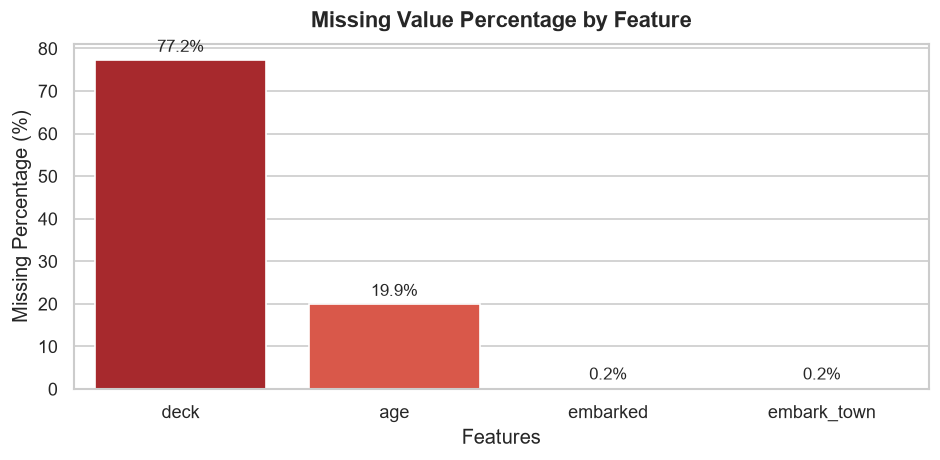

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("Features with Missing Values:")
display(missing_df)

# Missing values barplot visualization
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=missing_df.index, y=missing_df['Missing Percentage (%)'], palette='Reds_r')
plt.title('Missing Value Percentage by Feature', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Features')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                textcoords='offset points')
plt.tight_layout()
plt.show()

## 4. Primary Outcome Analysis: Survival Distribution
Examining overall survival rates across the dataset.

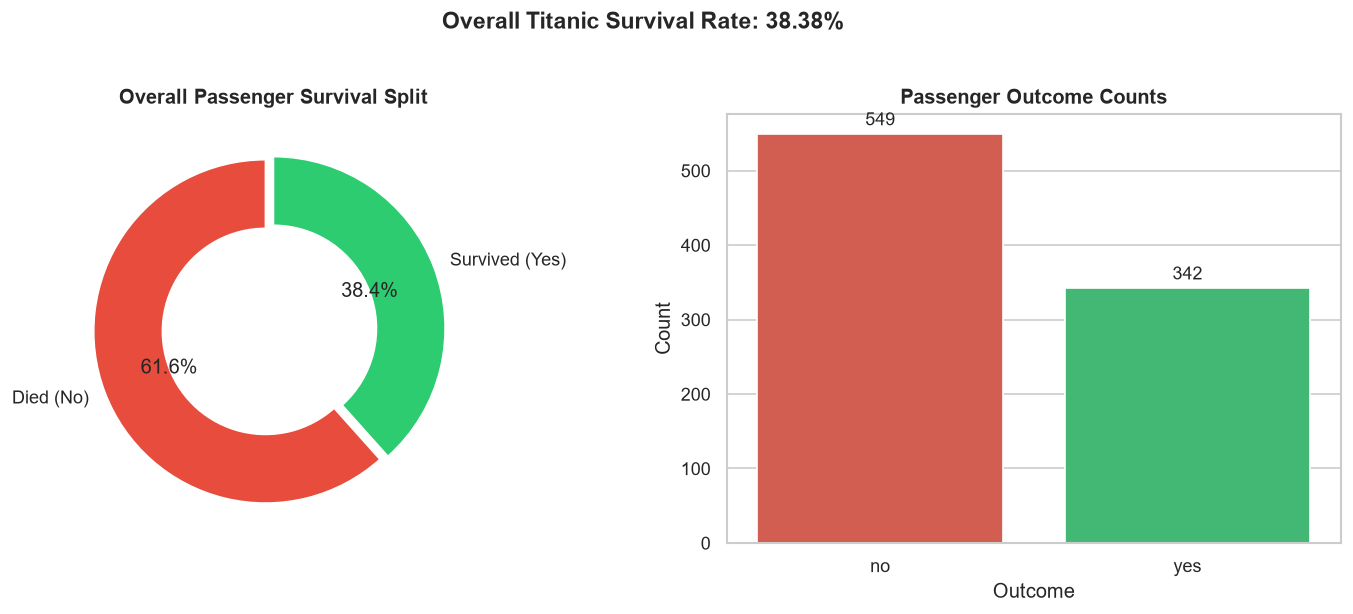

In [5]:
survived_counts = df['alive'].value_counts()
overall_survival_rate = df['survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart
axes[0].pie(survived_counts, labels=['Died (No)', 'Survived (Yes)'], autopct='%1.1f%%', 
            startangle=90, colors=['#e74c3c', '#2ecc71'], explode=(0.05, 0),
            wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title('Overall Passenger Survival Split', fontsize=12, fontweight='bold')

# Count plot
sns.countplot(x='alive', data=df, ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Passenger Outcome Counts', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

plt.suptitle(f'Overall Titanic Survival Rate: {overall_survival_rate:.2f}%', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Demographic Drivers of Survival (Gender & Age)
Investigating how age, sex, and demographic classification (`who`: man/woman/child) affected survival probabilities.

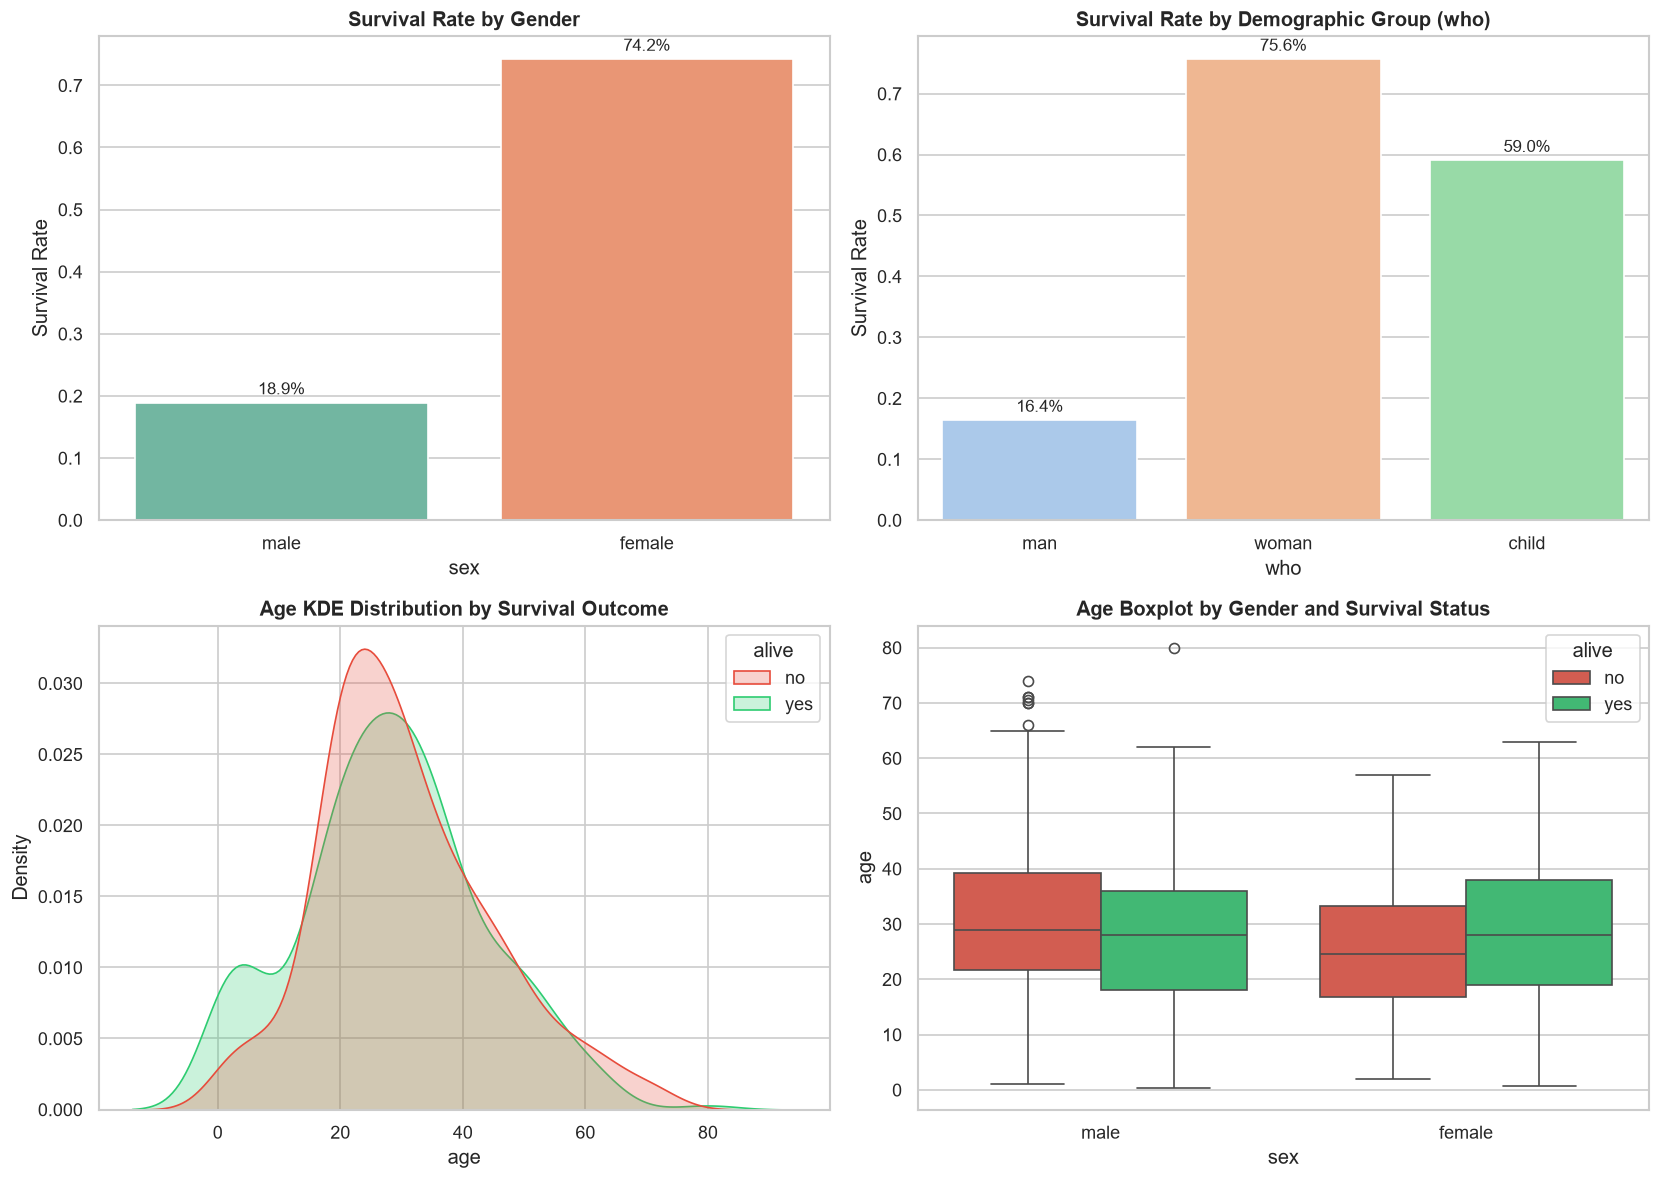

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival Rate by Gender
sns.barplot(x='sex', y='survived', data=df, ax=axes[0, 0], palette='Set2', ci=None)
axes[0, 0].set_title('Survival Rate by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Survival Rate')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

# 2. Survival Rate by Category (Who)
sns.barplot(x='who', y='survived', data=df, ax=axes[0, 1], palette='pastel', ci=None)
axes[0, 1].set_title('Survival Rate by Demographic Group (who)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

# 3. Age Density Distribution by Survival
sns.kdeplot(data=df, x='age', hue='alive', common_norm=False, fill=True, ax=axes[1, 0], palette=['#e74c3c', '#2ecc71'])
axes[1, 0].set_title('Age KDE Distribution by Survival Outcome', fontsize=12, fontweight='bold')

# 4. Age Spread across Gender & Survival
sns.boxplot(x='sex', y='age', hue='alive', data=df, ax=axes[1, 1], palette=['#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Age Boxplot by Gender and Survival Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Socioeconomic Analysis (Passenger Class & Ticket Fare)
Evaluating how passenger ticket class (`pclass`) and ticket fare impacted survival rates.

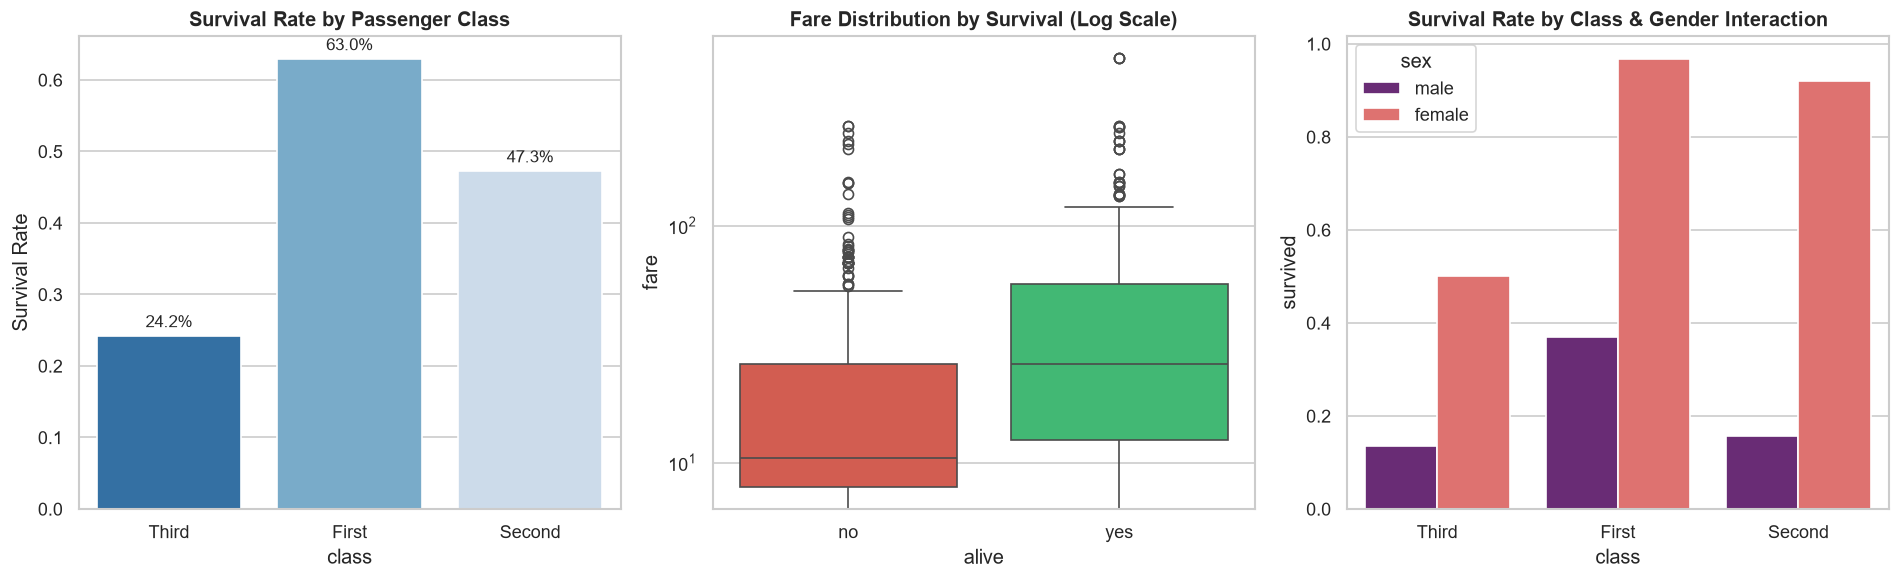

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Survival by Pclass
sns.barplot(x='class', y='survived', data=df, ax=axes[0], palette='Blues_r', ci=None)
axes[0].set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

# Fare Distribution (Log Scale)
sns.boxplot(x='alive', y='fare', data=df, ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_yscale('log')
axes[1].set_title('Fare Distribution by Survival (Log Scale)', fontsize=12, fontweight='bold')

# Survival by Class & Gender
sns.barplot(x='class', y='survived', hue='sex', data=df, ax=axes[2], palette='magma', ci=None)
axes[2].set_title('Survival Rate by Class & Gender Interaction', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Family Dynamics & Companionship
Analyzing family size (`family_size = sibsp + parch + 1`) and solo traveling status (`alone`).

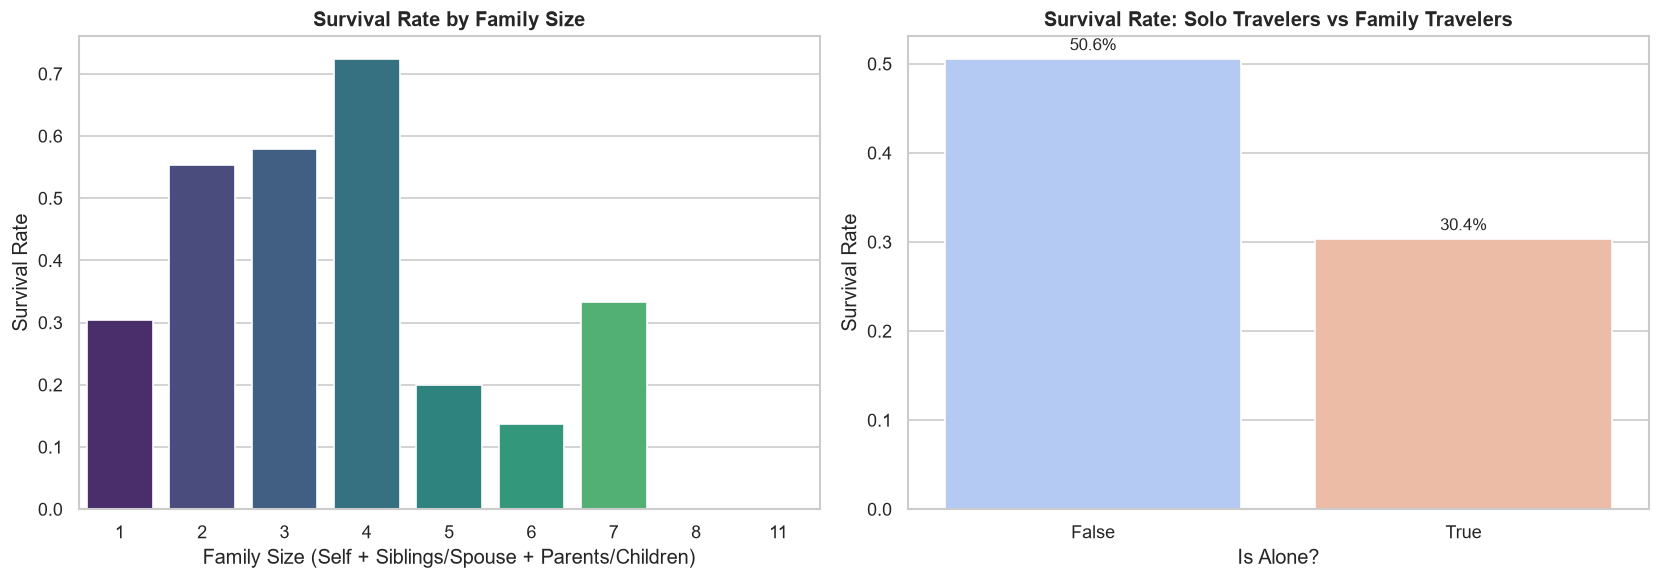

In [8]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival by Family Size
sns.barplot(x='family_size', y='survived', data=df, ax=axes[0], palette='viridis', ci=None)
axes[0].set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Family Size (Self + Siblings/Spouse + Parents/Children)')
axes[0].set_ylabel('Survival Rate')

# Survival by Alone Status
sns.barplot(x='alone', y='survived', data=df, ax=axes[1], palette='coolwarm', ci=None)
axes[1].set_title('Survival Rate: Solo Travelers vs Family Travelers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Is Alone?')
axes[1].set_ylabel('Survival Rate')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

## 8. Embarkation Port Dynamics
Analyzing passenger volume and survival patterns across embarkation towns (`Southampton`, `Cherbourg`, `Queenstown`).

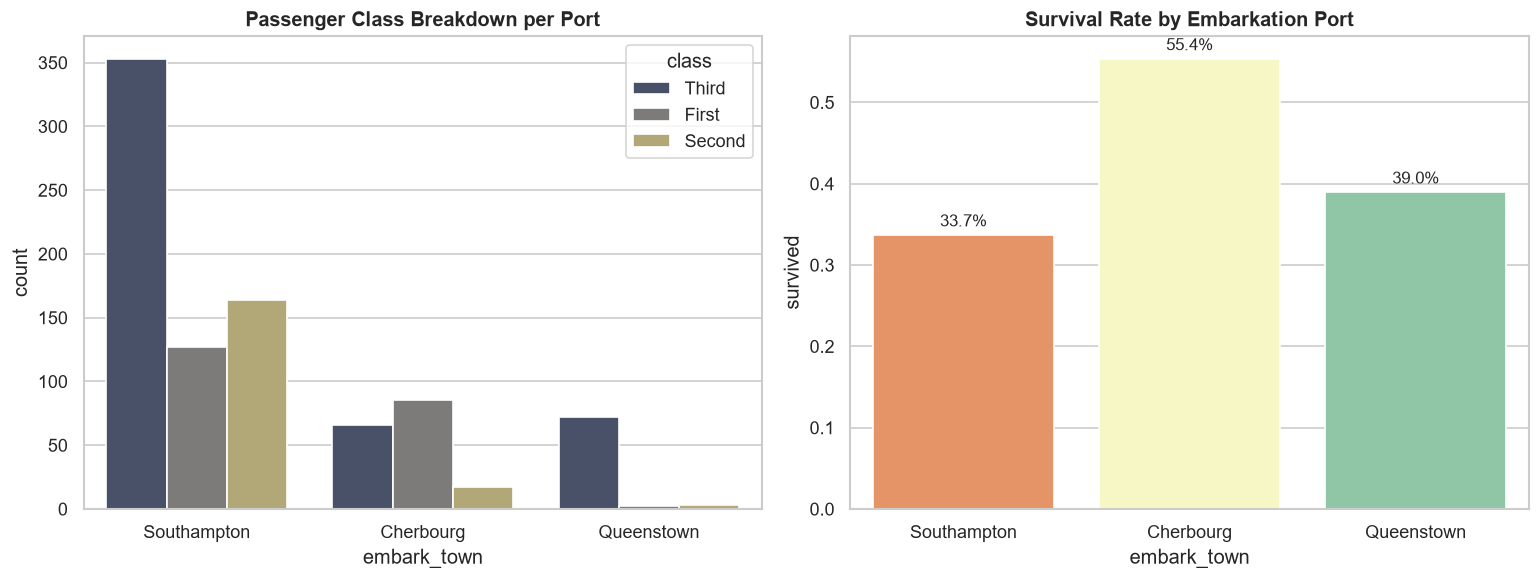

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x='embark_town', hue='class', data=df, ax=axes[0], palette='cividis')
axes[0].set_title('Passenger Class Breakdown per Port', fontsize=12, fontweight='bold')

sns.barplot(x='embark_town', y='survived', data=df, ax=axes[1], palette='Spectral', ci=None)
axes[1].set_title('Survival Rate by Embarkation Port', fontsize=12, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

## 9. Multivariate Correlation Matrix
Evaluating linear relationships between numerical features using Pearson correlation heatmap.

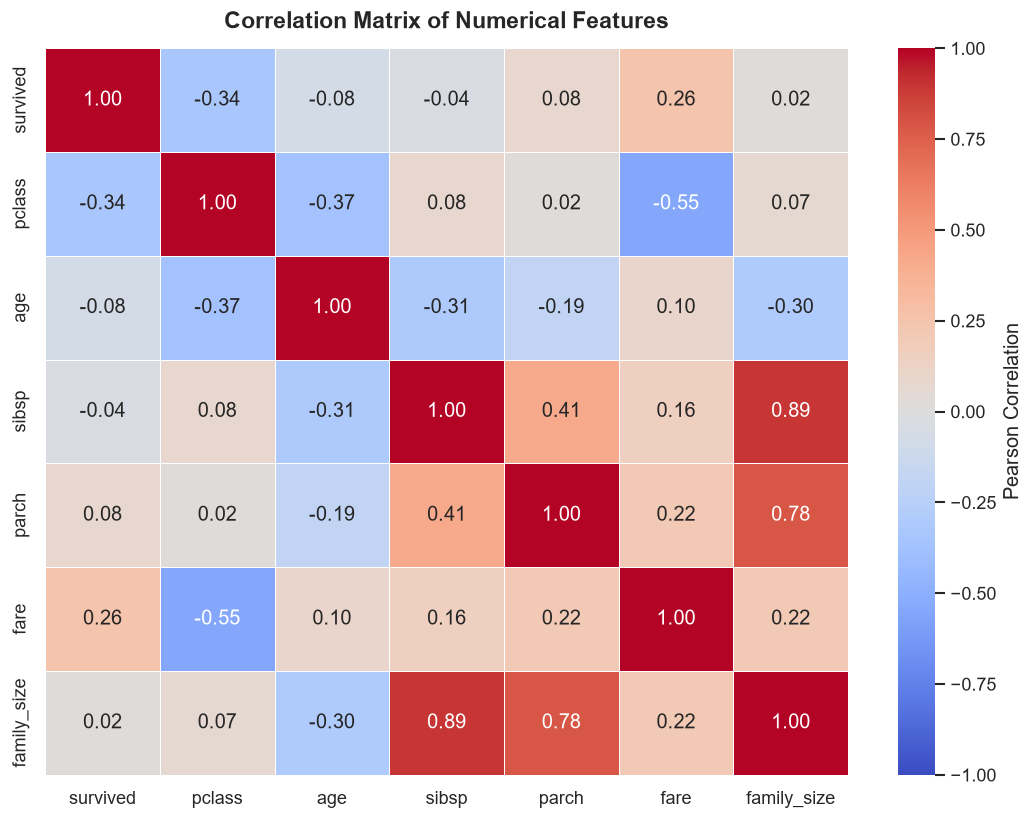

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 10. Key Insights & Data Analyst Takeaways
### Executive Summary of Key Findings:
1. **Gender Priority:** Female passengers had a **74.2%** survival rate compared to **18.9%** for male passengers.
2. **Class Distinction:** First-class passengers achieved a **63.0%** survival rate, while Third-class passengers had a **24.2%** survival rate.
3. **Age Influence:** Children had higher survival priority across all classes compared to adult males.
4. **Family Size Optimal Range:** Family sizes of 2-4 members yielded the highest survival probability (~55-70%), whereas solo travelers (~30%) and large families (5+ members) faced lower survival rates.
5. **Port Variance:** Cherbourg embarkations showed higher survival rates due to a higher proportion of First Class ticket holders.